<a href="https://colab.research.google.com/github/MiguelAngeloTr/Deep_Learning/blob/main/C2/UNET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explicación de la Arquitectura UNet

La arquitectura **U-Net**, diseñada principalmente esta diseñada para tareas de segmentación de imágenes

## Estructura General

La **U-Net** tiene dos partes principales:
1. **Contracción (encoder)**: A la izquierda de la "U", donde la red reduce la dimensionalidad de la imagen.
2. **Expansión (decoder)**: A la derecha de la "U", donde la red incrementa la dimensionalidad para obtener la segmentación de la imagen.

---

## Fase de Contracción (Encoder)

Este lado de la red actúa como un extractor de características, reduciendo la resolución de la imagen mientras aumenta la cantidad de canales (profundidad). En cada nivel de esta fase, se aplican operaciones de convolución y reducción mediante **max pooling**.

1. **Convoluciones** (en azul, flechas 3x3 ReLU): En cada capa se aplican dos convoluciones con filtros 3x3, seguidas de la función de activación ReLU. Esto genera mapas de características a partir de las imágenes de entrada.

2. **Max Pooling** (flechas rojas de 2x2): Después de las convoluciones, se realiza una operación de "max pooling" con un filtro 2x2 para reducir la resolución de la imagen a la mitad en cada paso, conservando solo las características más importantes. Esto ocurre en cada nivel de la fase de contracción.

A medida que se avanza hacia niveles más profundos, el tamaño espacial de la imagen disminuye (alto y ancho), pero la cantidad de canales aumenta (de 64 a 1024).

---

## Botella o Bottleneck

En el centro de la red, después de la fase de contracción, está la capa más profunda. Aquí, se obtiene el conjunto de características más comprimido de la imagen, con una gran cantidad de filtros (1024), pero con dimensiones espaciales reducidas. Es una capa de transición entre la fase de compresión y la de expansión.

---

## Fase de Expansión (Decoder)

Este lado de la red es responsable de reconstruir la imagen de salida desde la representación comprimida. En esta fase, la red realiza una serie de convoluciones transpuestas para aumentar la resolución de la imagen y recuperar las características necesarias para una segmentación precisa.

1. **Convoluciones transpuestas (Up-Convoluciones)** (flechas verdes de 2x2): Se aplican convoluciones transpuestas con filtros 2x2 para aumentar la resolución de la imagen, devolviéndola gradualmente a su tamaño original.

2. **Copiar y combinar (Skip Connections)**: Las flechas grises horizontales indican las **conexiones de salto**. En cada nivel de la fase de expansión, las características de las capas correspondientes en el encoder se copian y concatenan con la salida del decoder de la misma resolución. Esto ayuda a retener la información detallada que puede haberse perdido durante la fase de contracción.

3. **Convoluciones**: Después de concatenar las características del encoder, se aplican nuevamente convoluciones 3x3 seguidas de activaciones ReLU, lo que permite que la red afine las predicciones a medida que la resolución aumenta.

---

## Capa de salida

Finalmente, al final de la fase de expansión, hay una convolución con un filtro **1x1** (flecha verde oscuro) que convierte los mapas de características en un mapa de segmentación con el mismo tamaño espacial que la imagen de entrada, pero con un solo canal (o varios, dependiendo del número de clases).

---

## Resumen del Proceso

1. La imagen de entrada es procesada a través de la fase de contracción, donde se reduce la resolución y se extraen características.
2. En la fase de expansión, se aumenta de nuevo la resolución utilizando convoluciones transpuestas y se combinan características mediante las conexiones de salto para recuperar los detalles.
3. La salida es un mapa de segmentación donde cada píxel es clasificado según la estructura correspondiente en la imagen original.

Este enfoque permite que la red capture tanto los detalles finos (gracias a las conexiones de salto) como la información de contexto global (gracias a la fase de contracción).

La **UNet** es muy eficiente para tareas de segmentación en imágenes médicas, como segmentación de órganos o lesiones, donde es crucial identificar los bordes y detalles pequeños, pero también es importante contar con una vista general de la imagen.


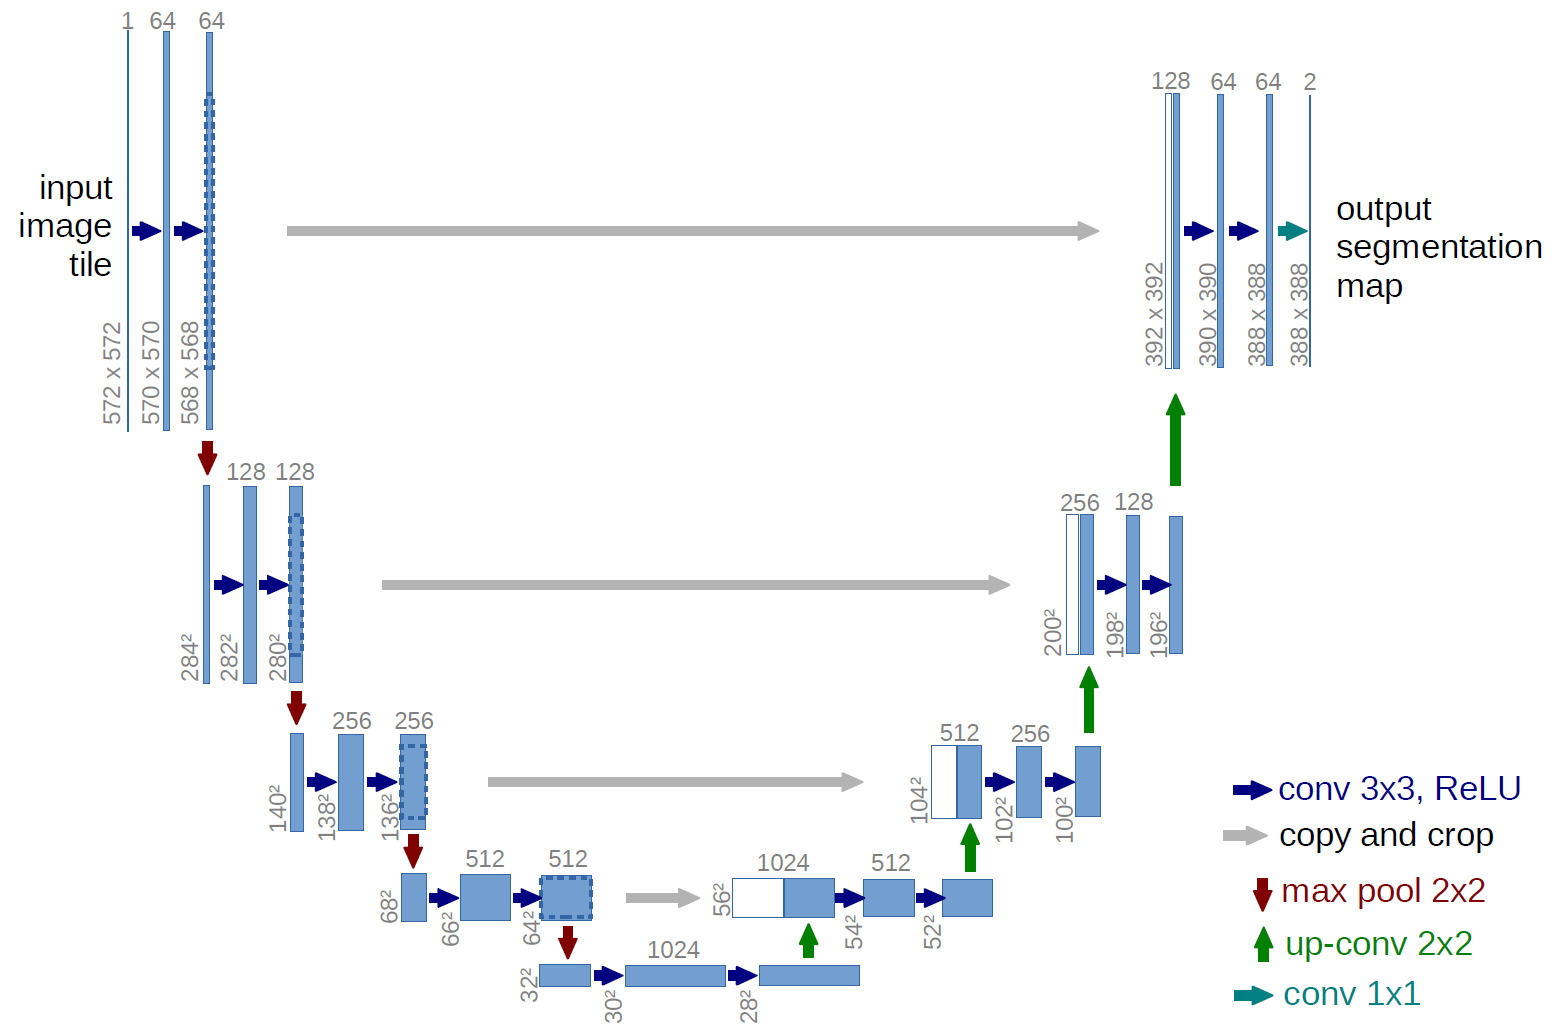

In [ ]:
!pip install tensorflow tensorflow_datasets matplotlib opencv-python

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
# Descarga y preprocesamiento del dataset Oxford Pets
dataset = tfds.load('oxford_iiit_pet:3.*.*', with_info=False)

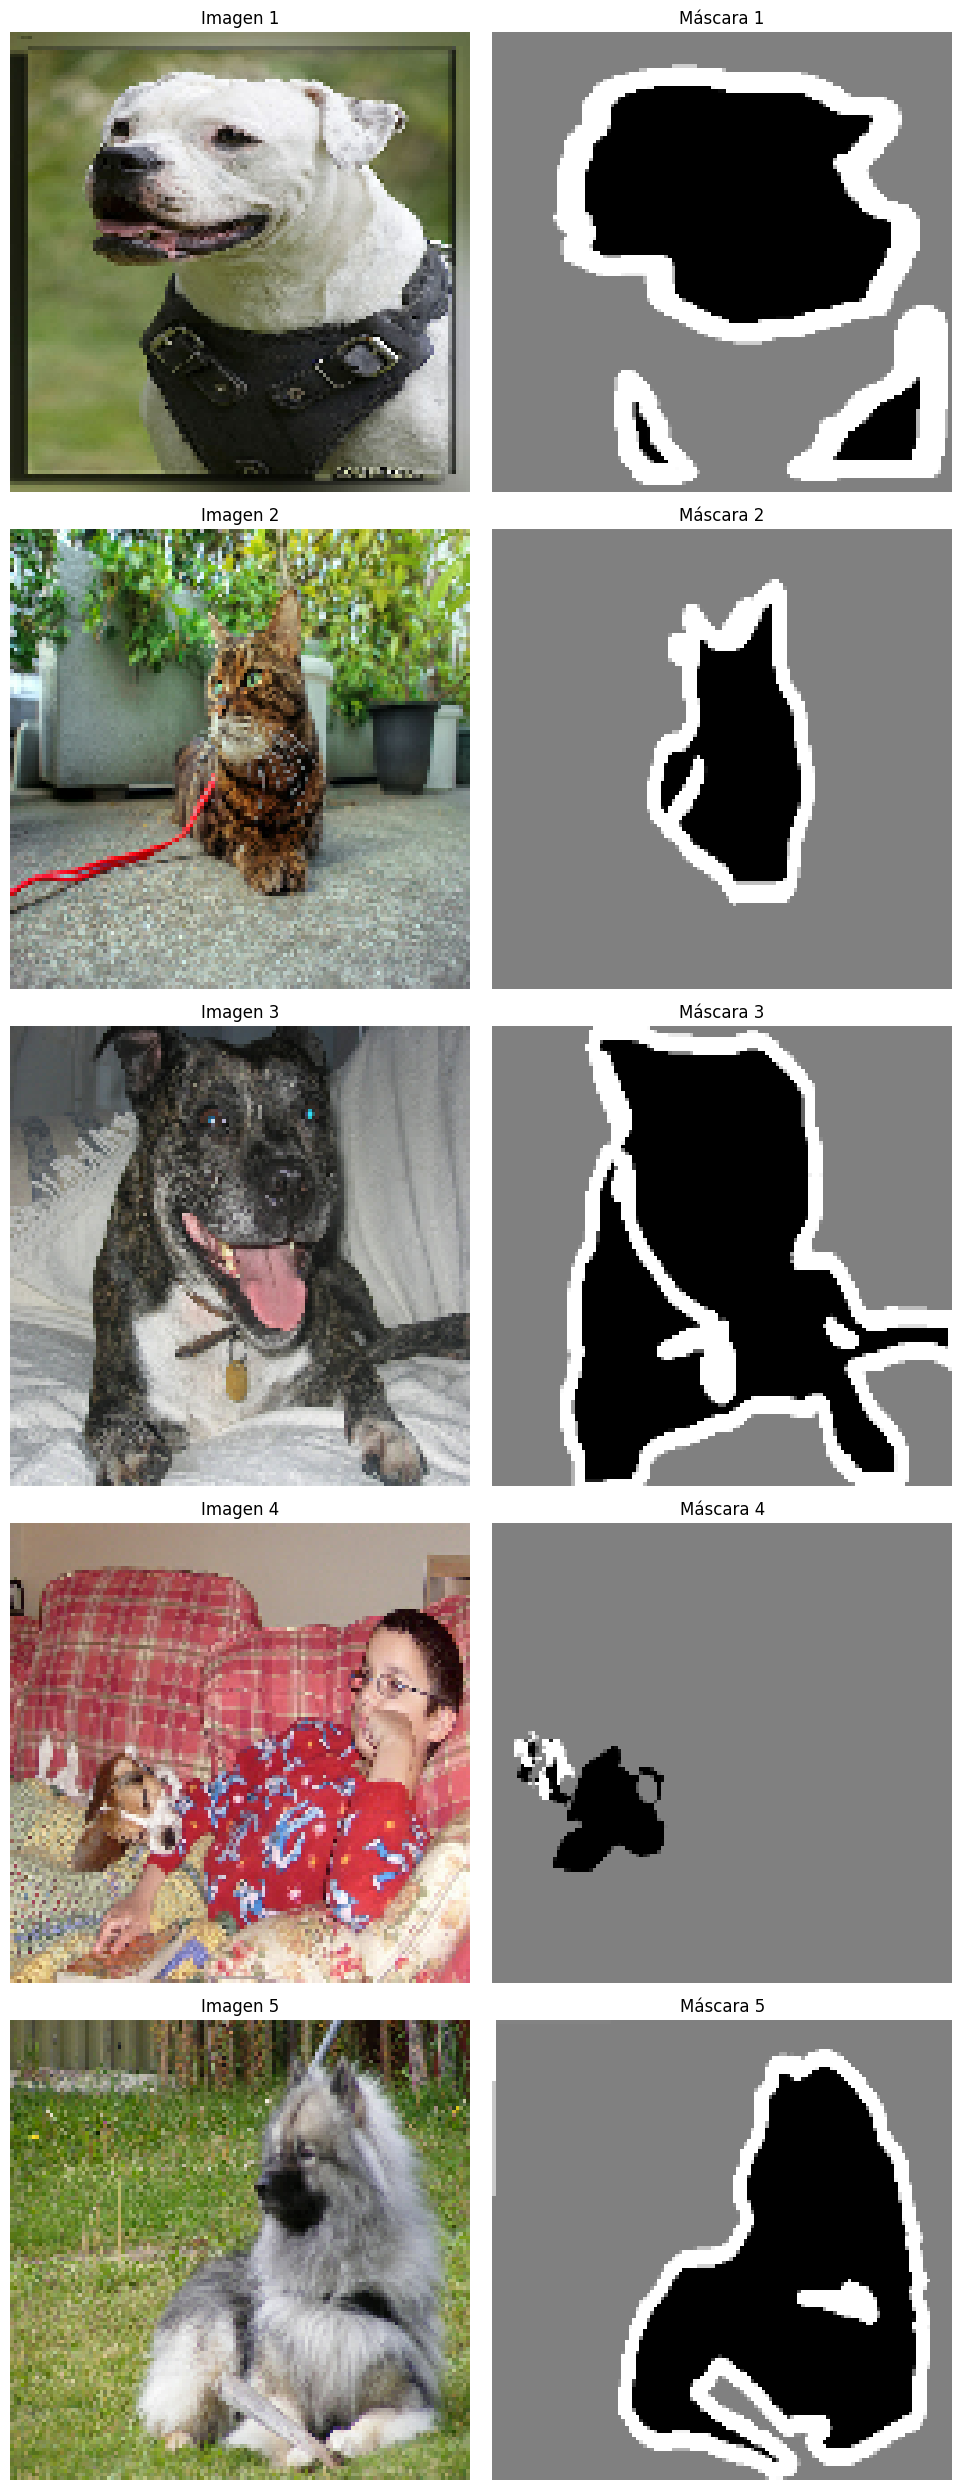

In [ ]:
def normalize(input_image, input_mask):
    """Normaliza la imagen entre 0 y 1, y la máscara en 0 o 1"""
    input_image = tf.cast(input_image, tf.float32) / 255.0
    input_mask = tf.cast(input_mask, tf.float32) / 255.0
    return input_image, input_mask

def load_image(datapoint):
    """Carga las imágenes y sus máscaras"""
    input_image = tf.image.resize(datapoint['image'], (128, 128))
    input_mask = tf.image.resize(datapoint['segmentation_mask'], (128, 128))
    input_image, input_mask = normalize(input_image, input_mask)
    return input_image, input_mask


def display_sample(dataset, num_samples=5):
    """
    Muestra algunas imágenes y sus correspondientes máscaras del dataset.

    Parameters:
    - dataset: el conjunto de datos de imágenes y máscaras (entrenamiento o prueba)
    - num_samples: número de imágenes y máscaras que se quieren visualizar
    """
    plt.figure(figsize=(10, 5 * num_samples))

    # Tomar un lote del dataset
    for images, masks in dataset.take(1):
        for i in range(num_samples):
            # Imagen
            plt.subplot(num_samples, 2, i * 2 + 1)
            plt.imshow(images[i].numpy())
            plt.title(f"Imagen {i+1}")
            plt.axis('off')

            # Máscara
            plt.subplot(num_samples, 2, i * 2 + 2)
            plt.imshow(masks[i].numpy().squeeze(), cmap='gray')
            plt.title(f"Máscara {i+1}")
            plt.axis('off')

    plt.tight_layout()
    plt.show()



# Preparación del conjunto de entrenamiento y validación
train_dataset = dataset['train'].map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = dataset['test'].map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

BATCH_SIZE = 32
BUFFER_SIZE = 1000

train_dataset = train_dataset.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()
train_dataset = train_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE)

# Llamada a la función para mostrar ejemplos del dataset de entrenamiento
display_sample(train_dataset)


In [ ]:

# Definición de la arquitectura U-Net
def unet_model(input_size=(128, 128, 3)):
    inputs = tf.keras.layers.Input(input_size)

    # Encoder
    c1 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = tf.keras.layers.MaxPooling2D((2, 2))(c1)

    c2 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = tf.keras.layers.MaxPooling2D((2, 2))(c2)

    c3 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = tf.keras.layers.MaxPooling2D((2, 2))(c3)

    c4 = tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    p4 = tf.keras.layers.MaxPooling2D((2, 2))(c4)

    # Bottleneck
    c5 = tf.keras.layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(p4)
    c5 = tf.keras.layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(c5)

    # Decoder
    u6 = tf.keras.layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = tf.keras.layers.concatenate([u6, c4])
    c6 = tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same')(u6)
    c6 = tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c6)

    u7 = tf.keras.layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = tf.keras.layers.concatenate([u7, c3])
    c7 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(u7)
    c7 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c7)

    u8 = tf.keras.layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = tf.keras.layers.concatenate([u8, c2])
    c8 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u8)
    c8 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c8)

    u9 = tf.keras.layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = tf.keras.layers.concatenate([u9, c1])
    c9 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u9)
    c9 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c9)

    outputs = tf.keras.layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = tf.keras.Model(inputs=[inputs], outputs=[outputs])
    return model

# Compilación del modelo
model = unet_model()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 128, 128, 64)   │          1,792 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 128, 128, 64)   │         36,928 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 64, 64, 64)     │              0 │ conv2d_1[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 64, 64, 128)    │         73,856 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 64, 64, 128)    │        147,584 │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 32, 32, 128)    │              0 │ conv2d_3[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 32, 32, 256)    │        295,168 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 32, 32, 256)    │        590,080 │ conv2d_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 16, 16, 256)    │              0 │ conv2d_5[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 16, 16, 512)    │      1,180,160 │ max_pooling2d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 16, 16, 512)    │      2,359,808 │ conv2d_6[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3           │ (None, 8, 8, 512)      │              0 │ conv2d_7[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)         │ (None, 8, 8, 1024)     │      4,719,616 │ max_pooling2d_3[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)         │ (None, 8, 8, 1024)     │      9,438,208 │ conv2d_8[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose          │ (None, 16, 16, 512)    │      2,097,664 │ conv2d_9[0][0]         │
│ (Conv2DTranspose)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 16, 16, 1024)   │              0 │ conv2d_transpose[0][0… │
│                      

 Total params: 31,031,745 (118.38 MB)

 Trainable params: 31,031,745 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenamiento del modelo
EPOCHS = 10


history = model.fit(
    train_data,                # Datos de entrenamiento
    epochs=EPOCHS,             # Número de épocas
    validation_data=test_data, # Datos de validación
    batch_size=32              # Tamaño del batch
)

# Evaluación del modelo
model.evaluate(test_dataset)

# Graficar los resultados del entrenamiento
def plot_metrics(history):
    """Función para graficar la precisión y pérdida del entrenamiento"""
    plt.figure(figsize=(12, 4))

    # Graficar precisión
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Validación')
    plt.title('Precisión')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend()

    # Graficar pérdida
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Entrenamiento')
    plt.plot(history.history['val_loss'], label='Validación')
    plt.title('Pérdida')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()

    plt.show()

plot_metrics(history)


Epoch 1/10
    486/Unknown 247s 389ms/step - accuracy: 0.0000e+00 - loss: 0.0702